In [1]:
!pip install  joblib tensorflow



In [2]:
# Upgrade XGBoost to the latest version
!pip install --upgrade xgboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 7.2 MB/s eta 0:00:00


In [3]:
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import load_model


In [4]:
CSV_PATH = "/content/drive/MyDrive/env_health_data.csv"

df = pd.read_csv(CSV_PATH)
print("Dataset Shape:", df.shape)
df.head(20)


Dataset Shape: (12000, 20)


,Source,House_ID,Indoor_Spore_Count,Outdoor_Spore_Count,Temperature_C,Relative_Humidity_%,Building_Type,Heating_System,Building_Age_yrs,Occupants,Water_Leakage,Leakage_History_Yrs,Child_Asthma_Status,Cough_Symptoms,Wheezing,Allergy_Symptoms,Fungal_Species_Aspergillus,Fungal_Species_Penicillium,Fungal_Species_Cladosporium,Fungal_Species_Stachybotrys
0,HEAL,H1,960,2946,22.9,71.6,Detached,Radiator,65,8,0,0,0,0,0,0,1,1,1,0
1,HEAL,H2,3872,13282,19.0,50.7,Apartment,Radiator,94,8,0,0,0,1,1,1,0,1,0,0
2,HEAL,H3,3192,8762,27.4,61.8,Apartment,Gas,12,3,1,10,0,0,1,0,1,0,0,0
3,HEAL,H4,566,14966,15.1,41.6,Apartment,Electric,100,7,0,0,0,1,0,1,0,0,0,0
4,HEAL,H5,4526,4135,18.3,62.5,Apartment,Heat Pump,36,1,0,0,0,1,1,1,0,0,0,0
5,HEAL,H6,3544,2999,24.1,80.0,Detached,Electric,24,5,0,0,1,0,0,1,0,0,1,0
6,HEAL,H7,3271,9738,16.5,59.8,Detached,Radiator,42,9,0,0,0,0,0,0,0,0,1,0
7,HEAL,H8,3019,4543,22.0,61.4,Detached,Electric,55,2,1,9,0,0,0,0,0,0,0,0
8,HEAL,H9,230,4889,21.5,35.6,Apartment,Gas,55,3,0,0,0,0,0,0,0,0,0,0
9,HEAL,H10,1785,13322,27.8,50.2,Apartment,Gas,89,4,0,0,0,0,1,0,1,0,0,0


In [5]:
# Check for missing values
print(df.isna().sum())

# Check column data types
print(df.dtypes)


Source                         0
House_ID                       0
Indoor_Spore_Count             0
Outdoor_Spore_Count            0
Temperature_C                  0
Relative_Humidity_%            0
Building_Type                  0
Heating_System                 0
Building_Age_yrs               0
Occupants                      0
Water_Leakage                  0
Leakage_History_Yrs            0
Child_Asthma_Status            0
Cough_Symptoms                 0
Wheezing                       0
Allergy_Symptoms               0
Fungal_Species_Aspergillus     0
Fungal_Species_Penicillium     0
Fungal_Species_Cladosporium    0
Fungal_Species_Stachybotrys    0
dtype: int64
Source                          object
House_ID                        object
Indoor_Spore_Count               int64
Outdoor_Spore_Count              int64
Temperature_C                  float64
Relative_Humidity_%            float64
Building_Type                   object
Heating_System                  object
Building_Age_yr

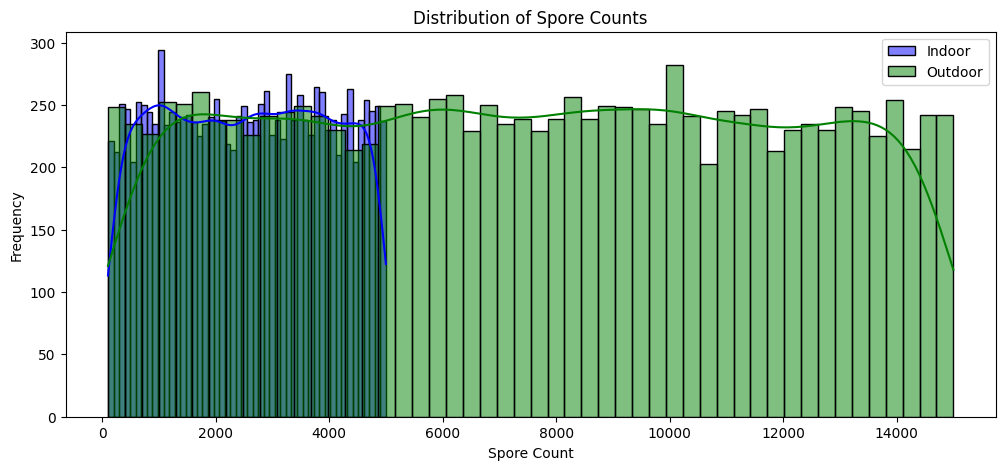

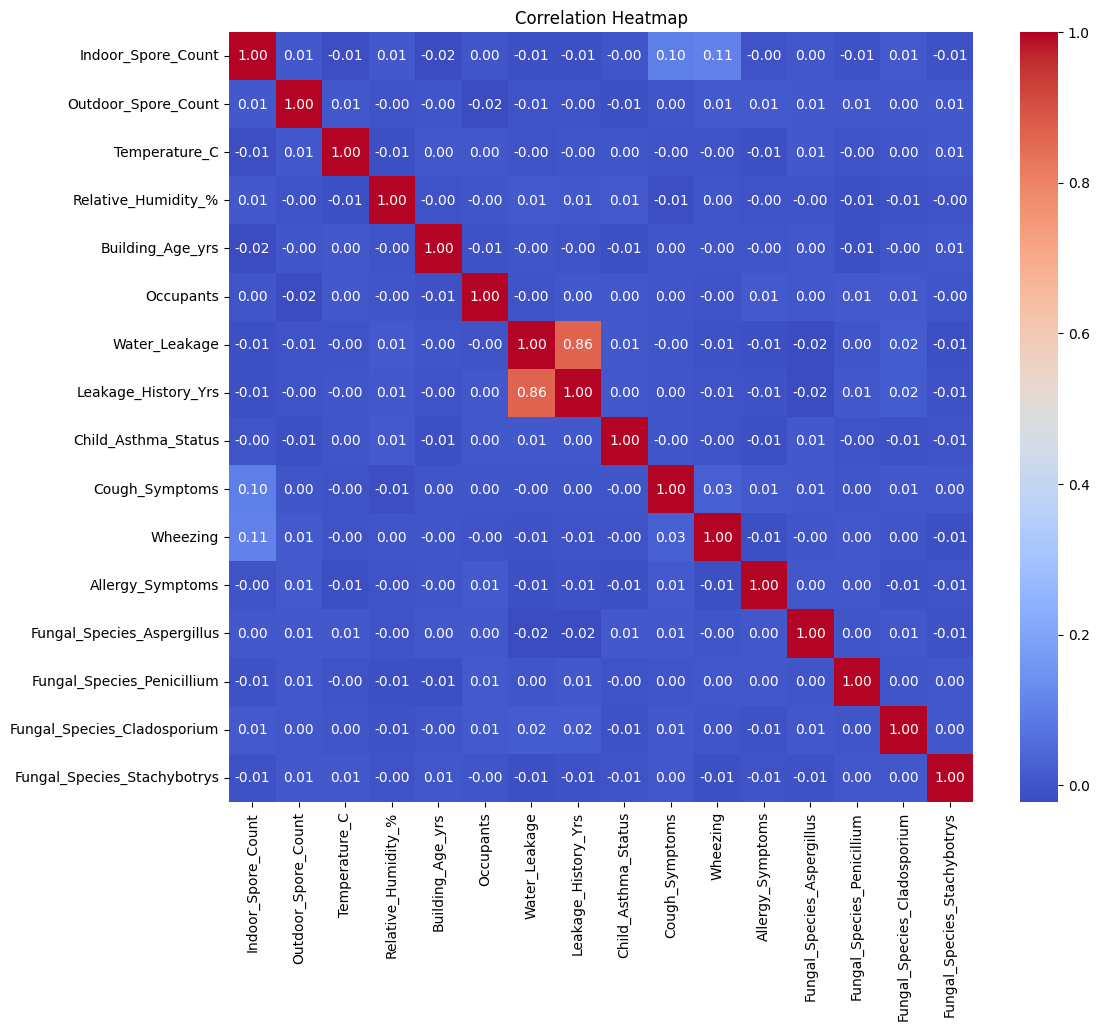

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Histogram of Indoor & Outdoor Spore Counts
plt.figure(figsize=(12,5))
sns.histplot(df['Indoor_Spore_Count'], bins=50, kde=True, color='blue', label='Indoor')
sns.histplot(df['Outdoor_Spore_Count'], bins=50, kde=True, color='green', label='Outdoor')
plt.title('Distribution of Spore Counts')
plt.xlabel('Spore Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [7]:
import numpy as np

np.random.seed(42)  # reproducibility

def mold_probability(row):
    """
    Calculate probability of mold based on multiple features:
    - Base probability: 0.1
    - Indoor > 1.3 * Outdoor: +0.4
    - High humidity (>65%): +0.2
    - Water leakage: +0.2
    - Leakage history >5 yrs: +0.1
    - Building age >50 yrs: +0.1
    - Fungal species presence: +0.05 per species
    """
    prob = 0.1

    if row['Indoor_Spore_Count'] > row['Outdoor_Spore_Count'] * 1.3:
        prob += 0.4

    if row['Relative_Humidity_%'] > 65:
        prob += 0.2

    if row['Water_Leakage'] == 1:
        prob += 0.2
        if row['Leakage_History_Yrs'] > 5:
            prob += 0.1

    if row['Building_Age_yrs'] > 50:
        prob += 0.1

    prob += 0.05 * (row['Fungal_Species_Aspergillus'] +
                     row['Fungal_Species_Penicillium'] +
                     row['Fungal_Species_Cladosporium'] +
                     row['Fungal_Species_Stachybotrys'])

    return min(prob, 0.95)

# Apply probability
df['Mold_Prob'] = df.apply(mold_probability, axis=1)

# Generate binary Mold target
df['Mold'] = df['Mold_Prob'].apply(lambda x: np.random.choice([1,0], p=[x, 1-x]))

# Optional string label
df['Mold_Label'] = df['Mold'].map({1: 'Mold', 0: 'No Mold'})

# Quick check
print(df[['Indoor_Spore_Count','Outdoor_Spore_Count','Relative_Humidity_%','Water_Leakage',
          'Leakage_History_Yrs','Building_Age_yrs','Mold_Prob','Mold','Mold_Label']].head(10))

print("\nMold value counts:")
print(df['Mold'].value_counts())


   Indoor_Spore_Count  Outdoor_Spore_Count  Relative_Humidity_%  \
0                 960                 2946                 71.6   
1                3872                13282                 50.7   
2                3192                 8762                 61.8   
3                 566                14966                 41.6   
4                4526                 4135                 62.5   
5                3544                 2999                 80.0   
6                3271                 9738                 59.8   
7                3019                 4543                 61.4   
8                 230                 4889                 35.6   
9                1785                13322                 50.2   

   Water_Leakage  Leakage_History_Yrs  Building_Age_yrs  Mold_Prob  Mold  \
0              0                    0                65       0.55     1   
1              0                    0                94       0.25     0   
2              1                  

In [8]:
# Check version to confirm upgrade
import xgboost as xgb
print("XGBoost version:", xgb.__version__)

XGBoost version: 3.1.2


In [9]:
# Install necessary packages (run this once in Colab)
!pip install xgboost lightgbm optuna imbalanced-learn

# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import optuna

# ------------------------
# 1. Prepare the data
# ------------------------
X = df.drop(columns=['House_ID', 'Source', 'Mold_Label', 'Mold_Prob', 'Mold'])
y = df['Mold']

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=['Building_Type', 'Heating_System'], drop_first=True)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE for class balance
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Optional scaling for LGBM / stacking meta-model
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# ------------------------
# 2. Hyperparameter tuning with Optuna
# ------------------------
def objective(trial):
    # Suggest parameters for XGBoost
    xgb_params = {
        'n_estimators': trial.suggest_int('xgb_n_estimators', 300, 1000),
        'max_depth': trial.suggest_int('xgb_max_depth', 3, 10),
        'learning_rate': trial.suggest_float('xgb_lr', 0.01, 0.2),
        'subsample': trial.suggest_float('xgb_subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('xgb_colsample', 0.6, 1.0),
        'use_label_encoder': False,
        'eval_metric': 'logloss',
        'random_state': 42
    }

    # Suggest parameters for LightGBM
    lgb_params = {
        'n_estimators': trial.suggest_int('lgb_n_estimators', 300, 1000),
        'max_depth': trial.suggest_int('lgb_max_depth', 3, 12),
        'learning_rate': trial.suggest_float('lgb_lr', 0.01, 0.2),
        'num_leaves': trial.suggest_int('lgb_num_leaves', 20, 150),
        'subsample': trial.suggest_float('lgb_subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('lgb_colsample', 0.6, 1.0),
        'random_state': 42
    }

    # Random Forest
    rf_params = {
        'n_estimators': trial.suggest_int('rf_n_estimators', 200, 700),
        'max_depth': trial.suggest_int('rf_max_depth', 5, 15),
        'class_weight': 'balanced',
        'random_state': 42
    }

    # Initialize base models
    xgb_clf = XGBClassifier(**xgb_params)
    lgb_clf = LGBMClassifier(**lgb_params)
    rf_clf = RandomForestClassifier(**rf_params)

    # Stacking ensemble
    stacking = StackingClassifier(
        estimators=[('xgb', xgb_clf), ('lgb', lgb_clf), ('rf', rf_clf)],
        final_estimator=RandomForestClassifier(n_estimators=200, random_state=42),
        cv=3,
        passthrough=True,
        n_jobs=-1
    )

    stacking.fit(X_train_res_scaled, y_train_res)
    y_prob = stacking.predict_proba(X_test_scaled)[:,1]

    # Automatic threshold tuning
    thresholds = np.arange(0.1, 0.9, 0.01)
    best_thresh = 0.5
    best_score = 0
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        score = 0.7 * accuracy_score(y_test, y_pred_t) + 0.3 * f1_score(y_test, y_pred_t)
        if score > best_score:
            best_score = score
            best_thresh = t

    return best_score

# Run Optuna optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best trial score:", study.best_value)
print("Best trial params:", study.best_params)

# ------------------------
# 3. Train final stacking with best params
# ------------------------
best_params = study.best_params

# Extract XGB params
xgb_params_final = {
    'n_estimators': best_params['xgb_n_estimators'],
    'max_depth': best_params['xgb_max_depth'],
    'learning_rate': best_params['xgb_lr'],
    'subsample': best_params['xgb_subsample'],
    'colsample_bytree': best_params['xgb_colsample'],
    'use_label_encoder': False,
    'eval_metric': 'logloss',
    'random_state': 42
}
xgb_clf_final = XGBClassifier(**xgb_params_final)

# Extract LGB params
lgb_params_final = {
    'n_estimators': best_params['lgb_n_estimators'],
    'max_depth': best_params['lgb_max_depth'],
    'learning_rate': best_params['lgb_lr'],
    'num_leaves': best_params['lgb_num_leaves'],
    'subsample': best_params['lgb_subsample'],
    'colsample_bytree': best_params['lgb_colsample'],
    'random_state': 42
}
lgb_clf_final = LGBMClassifier(**lgb_params_final)

# Random Forest
rf_clf_final = RandomForestClassifier(
    n_estimators=best_params['rf_n_estimators'],
    max_depth=best_params['rf_max_depth'],
    class_weight='balanced',
    random_state=42
)

# Final stacking ensemble
stacking_final = StackingClassifier(
    estimators=[('xgb', xgb_clf_final), ('lgb', lgb_clf_final), ('rf', rf_clf_final)],
    final_estimator=RandomForestClassifier(n_estimators=300, random_state=42),
    cv=3,
    passthrough=True,
    n_jobs=-1
)

stacking_final.fit(X_train_res_scaled, y_train_res)

# Predict probabilities
y_prob_final = stacking_final.predict_proba(X_test_scaled)[:,1]

# Threshold tuning
thresholds = np.arange(0.1, 0.9, 0.01)
best_thresh = 0.5
best_score = 0
for t in thresholds:
    y_pred_t = (y_prob_final >= t).astype(int)
    score = 0.7 * accuracy_score(y_test, y_pred_t) + 0.3 * f1_score(y_test, y_pred_t)
    if score > best_score:
        best_score = score
        best_thresh = t

# Final predictions
y_pred_final = (y_prob_final >= best_thresh).astype(int)

# ------------------------
# 4. Evaluate
# ------------------------
print(f"Optimal threshold (stacking + SMOTE + Optuna): {best_thresh:.2f}, Weighted Score: {best_score:.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_final, digits=4))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 6.1 MB/s eta 0:00:00


[I 2025-11-23 16:12:14,150] A new study created in memory with name: no-name-94c1d5b8-0c4c-4732-a99e-d9874073be33


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[I 2025-11-23 16:13:27,850] Trial 0 finished with value: 0.6333030667043527 and parameters: {'xgb_n_estimators': 458, 'xgb_max_depth': 7, 'xgb_lr': 0.1381598231933213, 'xgb_subsample': 0.9639688106220217, 'xgb_colsample': 0.8780080390067175, 'lgb_n_estimators': 808, 'lgb_max_depth': 9, 'lgb_lr': 0.1723604965000699, 'lgb_num_leaves': 73, 'lgb_subsample': 0.7431437001948791, 'lgb_colsample': 0.8909654995480614, 'rf_n_estimators': 555, 'rf_max_depth': 13}. Best is trial 0 with value: 0.6333030667043527.


...

[I 2025-11-23 16:38:17,941] Trial 28 finished with value: 0.6201363636363636 and parameters: {'xgb_n_estimators': 639, 'xgb_max_depth': 8, 'xgb_lr': 0.08993436744013777, 'xgb_subsample': 0.7162946997141302, 'xgb_colsample': 0.828962986118014, 'lgb_n_estimators': 550, 'lgb_max_depth': 4, 'lgb_lr': 0.1459831205924669, 'lgb_num_leaves': 93, 'lgb_subsample': 0.7889869235699392, 'lgb_colsample': 0.9739362888345018, 'rf_n_estimators': 561, 'rf_max_depth': 11}. Best is trial 0 with value: 0.6333030667043527.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[I 2025-11-23 16:39:00,889] Trial 29 finished with value: 0.6249585721107928 and parameters: {'xgb_n_estimators': 713, 'xgb_max_depth': 9, 'xgb_lr': 0.14355125011160516, 'xgb_subsample': 0.7788421208145732, 'xgb_colsample': 0.870188714746875, 'lgb_n_estimators': 495, 'lgb_max_depth': 8, 'lgb_lr': 0.12367634334932373, 'lgb_num_leaves': 84, 'lgb_subsample': 0.7485452530852965, 'lgb_colsample': 0.9545202144519505, 'rf_n_estimators': 270, 'rf_max_depth': 9}. Best is trial 0 with value: 0.6333030667043527.
Best trial score: 0.6333030667043527
Best trial params: {'xgb_n_estimators': 458, 'xgb_max_depth': 7, 'xgb_lr': 0.1381598231933213, 'xgb_subsample': 0.9639688106220217, 'xgb_colsample': 0.8780080390067175, 'lgb_n_estimators': 808, 'lgb_max_depth': 9, 'lgb_lr': 0.1723604965000699, 'lgb_num_leaves': 73, 'lgb_subsample': 0.7431437001948791, 'lgb_colsample': 0.8909654995480614, 'rf_n_estimators': 555, 'rf_max_depth': 13}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Optimal threshold (stacking + SMOTE + Optuna): 0.44, Weighted Score: 0.6327
Test Accuracy: 0.6650

Classification Report:
               precision    recall  f1-score   support

           0     0.7569    0.7060    0.7306      1544
           1     0.5271    0.5911    0.5573       856

    accuracy                         0.6650      2400
   macro avg     0.6420    0.6485    0.6439      2400
weighted avg     0.6750    0.6650    0.6688      2400



In [10]:
# Install necessary packages (run this once in Colab)
!pip install xgboost lightgbm optuna imbalanced-learn

# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import optuna

# ------------------------
# 1. Prepare the data
# ------------------------
X = df.drop(columns=['House_ID', 'Source', 'Mold_Label', 'Mold_Prob', 'Mold'])
y = df['Mold']

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=['Building_Type', 'Heating_System'], drop_first=True)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE for class balance
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Optional scaling for LGBM / stacking meta-model
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# ------------------------
# 2. Hyperparameter tuning with Optuna
# ------------------------
def objective(trial):
    # Suggest parameters for XGBoost
    xgb_params = {
        'n_estimators': trial.suggest_int('xgb_n_estimators', 300, 1000),
        'max_depth': trial.suggest_int('xgb_max_depth', 3, 10),
        'learning_rate': trial.suggest_float('xgb_lr', 0.01, 0.2),
        'subsample': trial.suggest_float('xgb_subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('xgb_colsample', 0.6, 1.0),
        'use_label_encoder': False,
        'eval_metric': 'logloss',
        'random_state': 42
    }

    # Suggest parameters for LightGBM
    lgb_params = {
        'n_estimators': trial.suggest_int('lgb_n_estimators', 300, 1000),
        'max_depth': trial.suggest_int('lgb_max_depth', 3, 12),
        'learning_rate': trial.suggest_float('lgb_lr', 0.01, 0.2),
        'num_leaves': trial.suggest_int('lgb_num_leaves', 20, 150),
        'subsample': trial.suggest_float('lgb_subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('lgb_colsample', 0.6, 1.0),
        'random_state': 42
    }

    # Random Forest
    rf_params = {
        'n_estimators': trial.suggest_int('rf_n_estimators', 200, 700),
        'max_depth': trial.suggest_int('rf_max_depth', 5, 15),
        'class_weight': 'balanced',
        'random_state': 42
    }

    # Initialize base models
    xgb_clf = XGBClassifier(**xgb_params)
    lgb_clf = LGBMClassifier(**lgb_params)
    rf_clf = RandomForestClassifier(**rf_params)

    # Stacking ensemble
    stacking = StackingClassifier(
        estimators=[('xgb', xgb_clf), ('lgb', lgb_clf), ('rf', rf_clf)],
        final_estimator=RandomForestClassifier(n_estimators=200, random_state=42),
        cv=3,
        passthrough=True,
        n_jobs=-1
    )

    stacking.fit(X_train_res_scaled, y_train_res)
    y_prob = stacking.predict_proba(X_test_scaled)[:,1]

    # Automatic threshold tuning
    thresholds = np.arange(0.1, 0.9, 0.01)
    best_thresh = 0.5
    best_score = 0
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        score = 0.7 * accuracy_score(y_test, y_pred_t) + 0.3 * f1_score(y_test, y_pred_t)
        if score > best_score:
            best_score = score
            best_thresh = t

    return best_score

# Run Optuna optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best trial score:", study.best_value)
print("Best trial params:", study.best_params)

# ------------------------
# 3. Train final stacking with best params
# ------------------------
best_params = study.best_params

# Extract XGB params
xgb_params_final = {
    'n_estimators': best_params['xgb_n_estimators'],
    'max_depth': best_params['xgb_max_depth'],
    'learning_rate': best_params['xgb_lr'],
    'subsample': best_params['xgb_subsample'],
    'colsample_bytree': best_params['xgb_colsample'],
    'use_label_encoder': False,
    'eval_metric': 'logloss',
    'random_state': 42
}
xgb_clf_final = XGBClassifier(**xgb_params_final)

# Extract LGB params
lgb_params_final = {
    'n_estimators': best_params['lgb_n_estimators'],
    'max_depth': best_params['lgb_max_depth'],
    'learning_rate': best_params['lgb_lr'],
    'num_leaves': best_params['lgb_num_leaves'],
    'subsample': best_params['lgb_subsample'],
    'colsample_bytree': best_params['lgb_colsample'],
    'random_state': 42
}
lgb_clf_final = LGBMClassifier(**lgb_params_final)

# Random Forest
rf_clf_final = RandomForestClassifier(
    n_estimators=best_params['rf_n_estimators'],
    max_depth=best_params['rf_max_depth'],
    class_weight='balanced',
    random_state=42
)

# Final stacking ensemble
stacking_final = StackingClassifier(
    estimators=[('xgb', xgb_clf_final), ('lgb', lgb_clf_final), ('rf', rf_clf_final)],
    final_estimator=RandomForestClassifier(n_estimators=300, random_state=42),
    cv=3,
    passthrough=True,
    n_jobs=-1
)

stacking_final.fit(X_train_res_scaled, y_train_res)

# Predict probabilities
y_prob_final = stacking_final.predict_proba(X_test_scaled)[:,1]

# Threshold tuning
thresholds = np.arange(0.1, 0.9, 0.01)
best_thresh = 0.5
best_score = 0
for t in thresholds:
    y_pred_t = (y_prob_final >= t).astype(int)
    score = 0.7 * accuracy_score(y_test, y_pred_t) + 0.3 * f1_score(y_test, y_pred_t)
    if score > best_score:
        best_score = score
        best_thresh = t

# Final predictions
y_pred_final = (y_prob_final >= best_thresh).astype(int)

# ------------------------
# 4. Evaluate
# ------------------------
print(f"Optimal threshold (stacking + SMOTE + Optuna): {best_thresh:.2f}, Weighted Score: {best_score:.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_final, digits=4))


[I 2025-11-23 16:42:16,698] A new study created in memory with name: no-name-5674b8a6-a767-4310-b3d3-2bfded29a02a


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[I 2025-11-23 16:43:14,787] Trial 0 finished with value: 0.6250450359389038 and parameters: {'xgb_n_estimators': 568, 'xgb_max_depth': 5, 'xgb_lr': 0.19709980286442597, 'xgb_subsample': 0.7631452082443884, 'xgb_colsample': 0.7467779756196551, 'lgb_n_estimators': 873, 'lgb_max_depth': 6, 'lgb_lr': 0.037783178141699555, 'lgb_num_leaves': 38, 'lgb_subsample': 0.9425301117958738, 'lgb_colsample': 0.762463142910935, 'rf_n_estimators': 615, 'rf_max_depth': 9}. Best is trial 0 with value: 0.6250450359389038.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

[I 2025-11-23 17:07:10,677] Trial 28 finished with value: 0.6228212317097614 and parameters: {'xgb_n_estimators': 636, 'xgb_max_depth': 6, 'xgb_lr': 0.05041286070224979, 'xgb_subsample': 0.9471445867704534, 'xgb_colsample': 0.8434728885508389, 'lgb_n_estimators': 528, 'lgb_max_depth': 4, 'lgb_lr': 0.19976575026472201, 'lgb_num_leaves': 58, 'lgb_subsample': 0.757985732600897, 'lgb_colsample': 0.88265133058147, 'rf_n_estimators': 463, 'rf_max_depth': 15}. Best is trial 27 with value: 0.6354730624232859.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[I 2025-11-23 17:08:03,088] Trial 29 finished with value: 0.6253424369747899 and parameters: {'xgb_n_estimators': 573, 'xgb_max_depth': 5, 'xgb_lr': 0.027916855094166793, 'xgb_subsample': 0.8936044537640548, 'xgb_colsample': 0.9361611496797422, 'lgb_n_estimators': 586, 'lgb_max_depth': 6, 'lgb_lr': 0.1978335319583932, 'lgb_num_leaves': 78, 'lgb_subsample': 0.7118473625571173, 'lgb_colsample': 0.9462357218892511, 'rf_n_estimators': 418, 'rf_max_depth': 14}. Best is trial 27 with value: 0.6354730624232859.
Best trial score: 0.6354730624232859
Best trial params: {'xgb_n_estimators': 611, 'xgb_max_depth': 5, 'xgb_lr': 0.052344942106378675, 'xgb_subsample': 0.8216696842715209, 'xgb_colsample': 0.8408997131999812, 'lgb_n_estimators': 587, 'lgb_max_depth': 4, 'lgb_lr': 0.1982187167007805, 'lgb_num_leaves': 83, 'lgb_subsample': 0.76286665401415, 'lgb_colsample': 0.8785656126700079, 'rf_n_estimators': 477, 'rf_max_depth': 14}


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Optimal threshold (stacking + SMOTE + Optuna): 0.45, Weighted Score: 0.6304
Test Accuracy: 0.6650

Classification Report:
               precision    recall  f1-score   support

           0     0.7517    0.7157    0.7332      1544
           1     0.5280    0.5736    0.5498       856

    accuracy                         0.6650      2400
   macro avg     0.6398    0.6446    0.6415      2400
weighted avg     0.6719    0.6650    0.6678      2400



In [17]:
from sklearn.linear_model import LogisticRegression

best_params = study.best_trial.params

# Rebuild models using best hyperparameters
best_xgb = XGBClassifier(
    n_estimators=best_params['xgb_n_estimators'],
    max_depth=best_params['xgb_max_depth'],
    learning_rate=best_params['xgb_lr'],
    subsample=best_params['xgb_subsample'],
    colsample_bytree=best_params['xgb_colsample'],
    random_state=42
)

best_lgb = LGBMClassifier(
    n_estimators=best_params['lgb_n_estimators'],
    max_depth=best_params['lgb_max_depth'],
    learning_rate=best_params['lgb_lr'],
    num_leaves=best_params['lgb_num_leaves'],
    subsample=best_params['lgb_subsample'],
    colsample_bytree=best_params['lgb_colsample'],
    random_state=42
)

best_rf = RandomForestClassifier(
    n_estimators=best_params['rf_n_estimators'],
    max_depth=best_params['rf_max_depth'],
    random_state=42
)

stacked = StackingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('lgb', best_lgb),
        ('rf', best_rf)
    ],
    final_estimator=LogisticRegression(max_iter=200),
    passthrough=True
)

stacked.fit(X_train, y_train)
y_pred = stacked.predict(X_test)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3426, number of negative: 6174
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007752 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1065
[LightGBM] [Info] Number of data points in the train set: 9600, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.356875 -> initscore=-0.588954
[LightGBM] [Info] Start training from score -0.588954
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
# Save model
joblib.dump(stacking_final, "mold_stacking_model.pkl")

# Save the threshold  selected
joblib.dump(best_thresh, "optimal_threshold.pkl")

# Save your one-hot encoder mapping
joblib.dump(X_train.columns.tolist(), "feature_columns.pkl")

print("Model, threshold, and feature columns saved successfully.")

Model, threshold, and feature columns saved successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.72      0.73      1544
           1       0.53      0.57      0.55       856

    accuracy                           0.67      2400
   macro avg       0.64      0.64      0.64      2400
weighted avg       0.67      0.67      0.67      2400



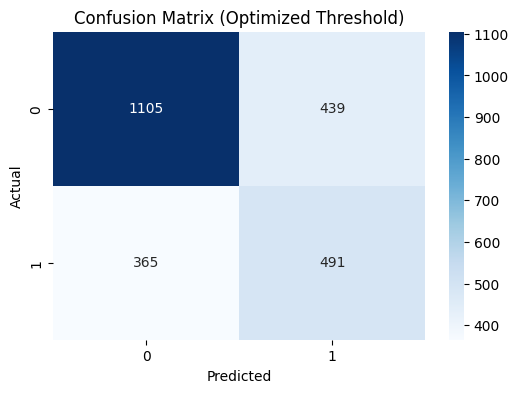

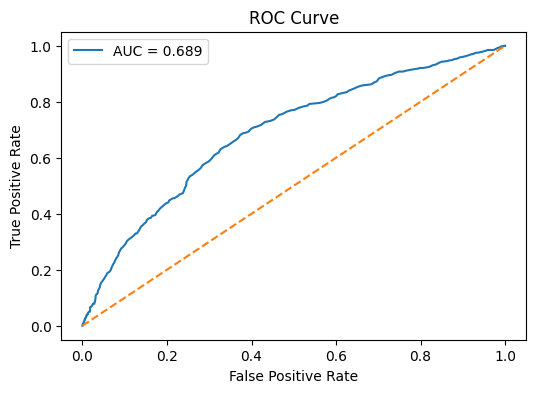

Model saved as final_stacked_model.pkl
Optimal threshold saved.


In [20]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

# -----------------------------
# 1. Predict probabilities
# -----------------------------
y_proba = stacking_final.predict_proba(X_test_scaled)[:, 1]

# -----------------------------
# 2. Apply optimal threshold
# -----------------------------
y_pred_opt = (y_proba >= best_thresh).astype(int)

# -----------------------------
# 3. Classification Report
# -----------------------------
print("Classification Report:")
print(classification_report(y_test, y_pred_opt))

# -----------------------------
# 4. Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred_opt)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Optimized Threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# 5. ROC Curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# -----------------------------
# 6. Save the model
# -----------------------------
joblib.dump(stacking_final, "final_stacked_model.pkl")
print("Model saved as final_stacked_model.pkl")

# Save threshold too
with open("best_threshold.json", "w") as f:
    json.dump({"threshold": float(best_thresh)}, f)

print("Optimal threshold saved.")

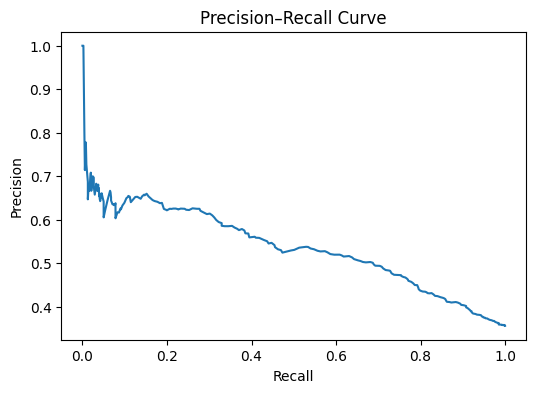

In [22]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

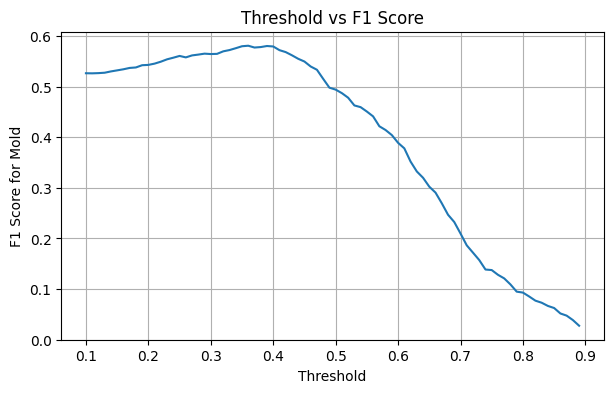

In [24]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for t in thresholds:
    pred = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, pred))

plt.figure(figsize=(7,4))
plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score for Mold")
plt.title("Threshold vs F1 Score")
plt.grid(True)
plt.show()

In [25]:
plt.savefig("confusion_matrix.png", dpi=300)
plt.savefig("roc_curve.png", dpi=300)
plt.savefig("pr_curve.png", dpi=300)
plt.savefig("threshold_vs_f1.png", dpi=300)


<Figure size 640x480 with 0 Axes>